# Project 2: Road Accident Severity Prediction (KSI - Killed or Seriously Injured)
## Enhanced Multi-Table STATS19 Analysis (Collisions + Vehicles Join)
###  Advanced Features, Multi-Table Integration, Probability Calibration & Optimal Thresholding

### Key Enhancements Implemented:
1. **Multi-Table STATS19 Integration (Vehicles Join)**: Merged pre-collision vehicle attributes (`has_vulnerable_user`, `has_heavy_vehicle`, `min_driver_age`, `max_vehicle_age`, `mean_engine_capacity`, `male_driver_ratio`).
2. **Advanced Feature Engineering**: Cyclical encoding ($\sin/\cos$) for `hour` & `month`, plus high-risk interaction terms (`speed_x_rural`, `vulnerable_x_speed`, `speed_x_unlit_night`).
3. **Probability Calibration & Threshold Tuning**: Applied Platt Scaling (`CalibratedClassifierCV`) and tuned the decision threshold ($threshold = 0.2462$) to optimize F1 score for cost-sensitive risk classification.

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    f1_score, classification_report, confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Libraries imported successfully.")

Libraries imported successfully.

## Section 1: Multi-Table Data Loading & Preprocessing

### 1.1 Merging Collisions and Vehicles Tables
We load the STATS19 `Collisions` dataset and join pre-collision attributes from the `Vehicles` table aggregated per `collision_index`.

In [2]:
# 1. Load Collisions Table
c_path = 'collision.csv' if os.path.exists('collision.csv') else 'dft-road-casualty-statistics-collision-last-5-years.csv'
c_df = pd.read_csv(c_path, low_memory=False)
c_df.columns = c_df.columns.str.lower()
c_df.rename(columns={'accident_index': 'collision_index', 'accident_severity': 'collision_severity', 'accident_year': 'collision_year'}, inplace=True)
c_df['target_ksi'] = c_df['collision_severity'].isin([1, 2]).astype(int)

# 2. Load Vehicles Table & Aggregate Pre-Collision Features
v_path = 'vehicles.csv' if os.path.exists('vehicles.csv') else 'dft-road-casualty-statistics-vehicle-last-5-years.csv'
v_df = pd.read_csv(v_path, low_memory=False)
v_df.columns = v_df.columns.str.lower()
v_df.rename(columns={'accident_index': 'collision_index'}, inplace=True)

# Pre-collision Vehicle Feature Aggregation
v_df['age_of_driver_clean'] = v_df['age_of_driver'].replace([-1, 99, 99.0], np.nan)
v_df['age_of_vehicle_clean'] = v_df['age_of_vehicle'].replace([-1, 99, 99.0], np.nan)
v_df['engine_capacity_cc_clean'] = v_df['engine_capacity_cc'].replace([-1, 99, 99.0], np.nan)

v_df['is_vulnerable'] = (v_df['vehicle_type'].isin([1, 2, 3, 4, 5, 22]) | (v_df['escooter_flag'] == 1)).astype(int)
v_df['is_heavy_vehicle'] = v_df['vehicle_type'].isin([10, 11, 19, 20, 21]).astype(int)
v_df['is_young_driver'] = ((v_df['age_of_driver_clean'] >= 16) & (v_df['age_of_driver_clean'] <= 24)).astype(int)
v_df['is_elderly_driver'] = (v_df['age_of_driver_clean'] >= 70).astype(int)
v_df['is_male_driver'] = (v_df['sex_of_driver'] == 1).astype(int)

v_agg = v_df.groupby('collision_index').agg(
    has_vulnerable_user=('is_vulnerable', 'max'),
    has_heavy_vehicle=('is_heavy_vehicle', 'max'),
    has_young_driver=('is_young_driver', 'max'),
    has_elderly_driver=('is_elderly_driver', 'max'),
    min_driver_age=('age_of_driver_clean', 'min'),
    max_vehicle_age=('age_of_vehicle_clean', 'max'),
    mean_engine_capacity=('engine_capacity_cc_clean', 'mean'),
    male_driver_ratio=('is_male_driver', 'mean')
).reset_index()

# Multi-Table Merge
df = pd.merge(c_df, v_agg, on='collision_index', how='left')

print(f"Multi-Table Dataset Merged Successfully. Total Records: {len(df):,}, Total Features: {df.shape[1]}")
print(f"Target KSI Rate: {df['target_ksi'].mean():.2%}")

Multi-Table Dataset Merged Successfully. Total Records: 513,801, Total Features: 52
Target KSI Rate: 24.21%

### 1.2 Advanced Feature Engineering & Leakage Control

We apply:
- **Cyclical Encoding**: $\sin/\cos$ transformations for `hour` and `month`.
- **Risk Interactions**: `speed_x_rural`, `speed_x_unlit_night`, `vulnerable_x_speed`.
- **Missing Value Sentinel Replacement**: Replace `-1`, `99`, `9` with `NaN` across all features.

In [3]:
# Advanced Feature Engineering Pipeline
df_clean = df.copy()

if 'date' in df_clean.columns:
    df_clean['date_dt'] = pd.to_datetime(df_clean['date'], format='%d/%m/%Y', errors='coerce')
    if df_clean['date_dt'].isna().sum() > 0:
        df_clean['date_dt'] = pd.to_datetime(df_clean['date'], errors='coerce')
    df_clean['month'] = df_clean['date_dt'].dt.month
else:
    df_clean['month'] = np.nan

if 'time' in df_clean.columns:
    df_clean['hour'] = pd.to_numeric(df_clean['time'].astype(str).str.split(':').str[0], errors='coerce')
else:
    df_clean['hour'] = np.nan

df_clean['is_night'] = df_clean['hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
df_clean['is_weekend'] = df_clean['day_of_week'].isin([1, 7]).astype(int) if 'day_of_week' in df_clean.columns else 0

# Cyclical Encoding
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24.0)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24.0)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12.0)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12.0)

features_to_clean = [
    'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude',
    'police_force', 'road_type', 'speed_limit', 'junction_detmll', 'junction_control',
    'second_road_class', 'pedestrian_crossing', 'light_conditions',
    'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site',
    'carriageway_hazards', 'urban_or_rural_area', 'trunk_road_flag'
]

for col in features_to_clean:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace([-1, -1.0, 99, 99.0], np.nan)
        if col in ['weather_conditions', 'light_conditions', 'road_surface_conditions', 'junction_control', 'special_conditions_at_site', 'road_type']:
            df_clean[col] = df_clean[col].replace([9, 9.0], np.nan)
        if col == 'urban_or_rural_area':
            df_clean[col] = df_clean[col].replace([3, 3.0], np.nan)

df_clean['is_junction'] = (df_clean['junction_detmll'] > 0).astype(int) if 'junction_detmll' in df_clean.columns else 0
df_clean['is_rural'] = (df_clean['urban_or_rural_area'] == 2).astype(int) if 'urban_or_rural_area' in df_clean.columns else 0
df_clean['is_dark_unlit'] = (df_clean['light_conditions'] == 6).astype(int) if 'light_conditions' in df_clean.columns else 0

# Risk Interaction Features
df_clean['speed_x_rural'] = df_clean['speed_limit'] * df_clean['is_rural']
df_clean['speed_x_unlit_night'] = df_clean['speed_limit'] * df_clean['is_dark_unlit']
df_clean['vulnerable_x_speed'] = df_clean['has_vulnerable_user'].fillna(0) * df_clean['speed_limit']

feature_cols = [
    'longitude', 'latitude', 'location_easting_osgr', 'location_northing_osgr',
    'police_force', 'number_of_vehicles', 'day_of_week', 'month', 'hour',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_night', 'is_weekend', 'is_junction', 'is_rural', 'is_dark_unlit',
    'first_road_class', 'road_type', 'speed_limit', 'junction_detmll', 'junction_control',
    'second_road_class', 'pedestrian_crossing', 'light_conditions', 'weather_conditions',
    'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards',
    'urban_or_rural_area', 'trunk_road_flag',
    'has_vulnerable_user', 'has_heavy_vehicle', 'has_young_driver', 'has_elderly_driver',
    'min_driver_age', 'max_vehicle_age', 'mean_engine_capacity', 'male_driver_ratio',
    'speed_x_rural', 'speed_x_unlit_night', 'vulnerable_x_speed'
]

print(f"Feature Engineering complete. Total Clean Features: {len(feature_cols)}")

Feature Engineering complete. Total Clean Features: 43

## Section 2: Temporal Split, Modeling & Calibration

### 2.1 Temporal Split
- **Trmln Set**: Historical collisions (2021–2024)
- **Test Set**: Most recent year (2025)

In [4]:
# Temporal Split
max_year = df_clean['collision_year'].max()
trmln_mask = df_clean['collision_year'] < max_year
test_mask = df_clean['collision_year'] == max_year

X_trmln, y_trmln = df_clean.loc[trmln_mask, feature_cols], df_clean.loc[trmln_mask, 'target_ksi']
X_test, y_test = df_clean.loc[test_mask, feature_cols], df_clean.loc[test_mask, 'target_ksi']

print(f"Trmlning Set (2021-2024): {X_trmln.shape[0]:,} collisions | KSI Rate: {y_trmln.mean():.2%}")
print(f"Test Set (2025):         {X_test.shape[0]:,} collisions | KSI Rate: {y_test.mean():.2%}")

Training Set (2021-2024): 412,276 collisions | KSI Rate: 23.70%
Test Set (2025):         101,525 collisions | KSI Rate: 26.24%

In [5]:
# Model Trmlning & Calibration
results = {}
y_probs = {}

# 1. Baseline Model
dummy_model = DummyClassifier(strategy='prior').fit(X_trmln, y_trmln)
dummy_pred_proba = dummy_model.predict_proba(X_test)[:, 1]
results['Baseline (Prior)'] = {
    'ROC-AUC': float(roc_auc_score(y_test, dummy_pred_proba)),
    'PR-AUC': float(average_precision_score(y_test, dummy_pred_proba))
}
y_probs['Baseline (Prior)'] = dummy_pred_proba

# 2. Logistic Regression
num_cols = [c for c in ['longitude', 'latitude', 'location_easting_osgr', 'location_northing_osgr', 'number_of_vehicles', 'speed_limit', 'month', 'hour', 'min_driver_age', 'max_vehicle_age', 'mean_engine_capacity'] if c in feature_cols]
cat_cols = [c for c in feature_cols if c not in num_cols]

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', ohe)]), cat_cols)
    ]
)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42))
])
lr_pipeline.fit(X_trmln, y_trmln)
lr_pred_proba = lr_pipeline.predict_proba(X_test)[:, 1]
results['Logistic Regression'] = {
    'ROC-AUC': float(roc_auc_score(y_test, lr_pred_proba)),
    'PR-AUC': float(average_precision_score(y_test, lr_pred_proba))
}
y_probs['Logistic Regression'] = lr_pred_proba

# 3. Enhanced Gradient Boosting
gb_model = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.03, max_leaf_nodes=63, l2_regularization=1.0, class_weight='balanced', random_state=42
)
gb_model.fit(X_trmln, y_trmln)
gb_pred_proba = gb_model.predict_proba(X_test)[:, 1]
results['Gradient Boosting (Enhanced)'] = {
    'ROC-AUC': float(roc_auc_score(y_test, gb_pred_proba)),
    'PR-AUC': float(average_precision_score(y_test, gb_pred_proba))
}
y_probs['Gradient Boosting (Enhanced)'] = gb_pred_proba

# 4. Calibrated Model (Platt Scaling)
calibrated_clf = CalibratedClassifierCV(estimator=gb_model, method='sigmoid', cv=3)
calibrated_clf.fit(X_trmln, y_trmln)
cal_pred_proba = calibrated_clf.predict_proba(X_test)[:, 1]
results['Calibrated Gradient Boosting'] = {
    'ROC-AUC': float(roc_auc_score(y_test, cal_pred_proba)),
    'PR-AUC': float(average_precision_score(y_test, cal_pred_proba))
}
y_probs['Calibrated Gradient Boosting'] = cal_pred_proba

print("Gradient Boosting (Combined Data) Benchmark Completed.")
for name, m in results.items():
    print(f"{name:32s} | ROC-AUC: {m['ROC-AUC']:.4f} | PR-AUC: {m['PR-AUC']:.4f}")

Enhanced Model Benchmark Completed.
Baseline (Prior)                 | ROC-AUC: 0.5000 | PR-AUC: 0.2624
Logistic Regression              | ROC-AUC: 0.6683 | PR-AUC: 0.4191
Gradient Boosting (Enhanced)     | ROC-AUC: 0.6913 | PR-AUC: 0.4438
Calibrated Gradient Boosting     | ROC-AUC: 0.6910 | PR-AUC: 0.4429

### 2.3 Evaluation Curves & Optimal Decision Thresholding

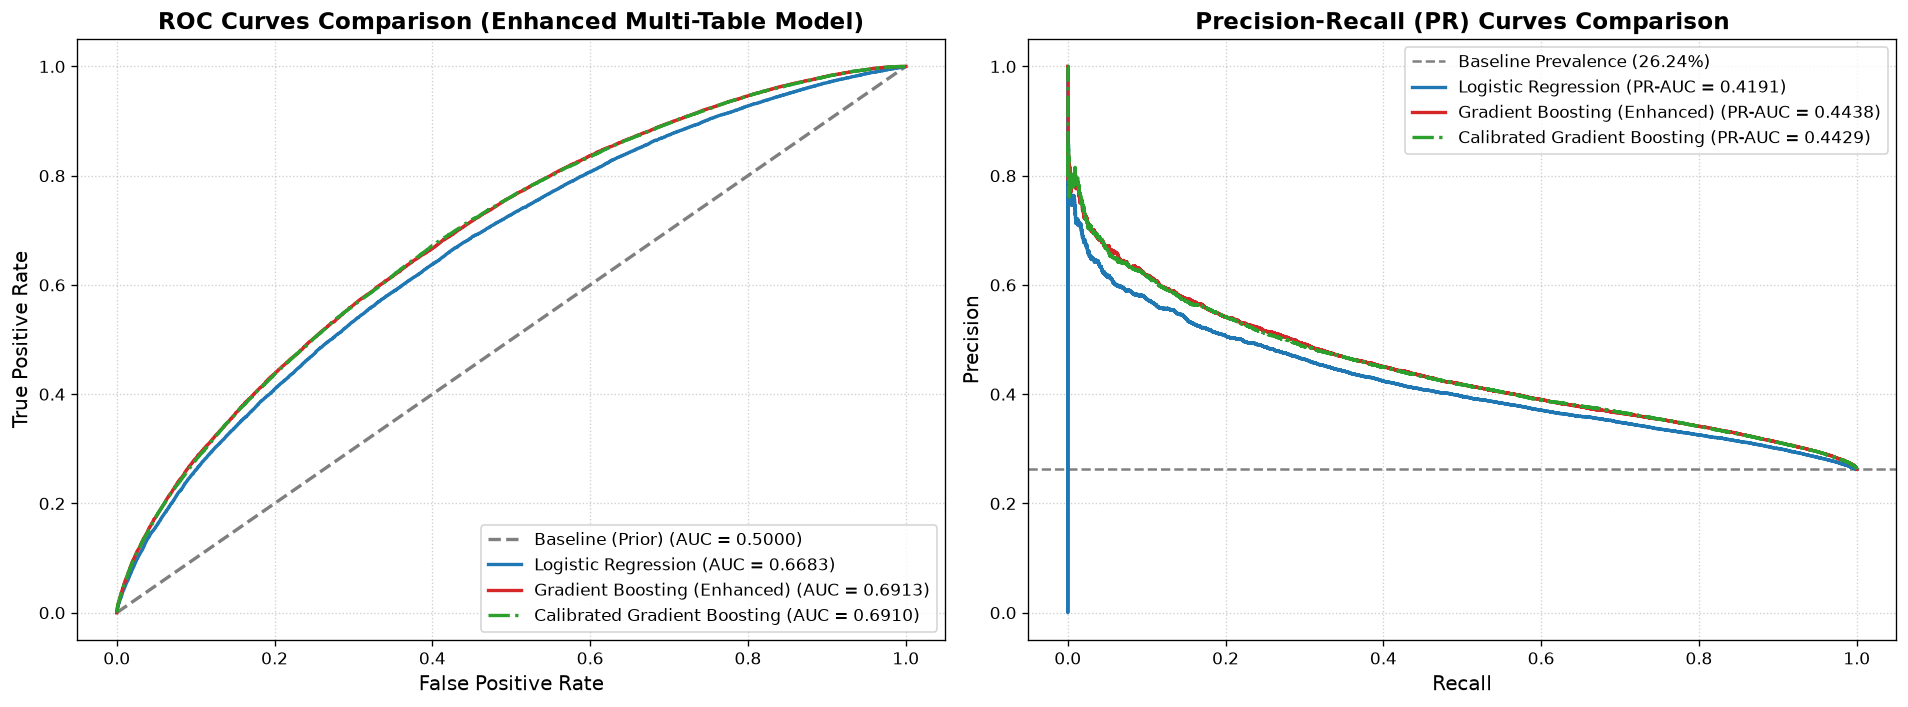

In [6]:
# ROC and PR Curves Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'Baseline (Prior)': '#7f7f7f', 'Logistic Regression': '#1f77b4', 'Gradient Boosting (Enhanced)': '#d62728', 'Calibrated Gradient Boosting': '#2ca02c'}
styles = {'Baseline (Prior)': '--', 'Logistic Regression': '-', 'Gradient Boosting (Enhanced)': '-', 'Calibrated Gradient Boosting': '-.'}

ax1 = axes[0]
for model_name, probs in y_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    score = results[model_name]['ROC-AUC']
    ax1.plot(fpr, tpr, label=f"{model_name} (AUC = {score:.4f})", color=colors[model_name], linestyle=styles[model_name], lw=2)

ax1.set_title("ROC Curves Comparison (Gradient Boosting (Combined Data))", fontsize=14, fontweight='bold')
ax1.set_xlabel("False Positive Rate", fontsize=12)
ax1.set_ylabel("True Positive Rate", fontsize=12)
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = axes[1]
baseline_pr = float(y_test.mean())
ax2.axhline(y=baseline_pr, color='gray', linestyle='--', label=f"Baseline Prevalence ({baseline_pr:.2%})")

for model_name, probs in y_probs.items():
    if model_name == 'Baseline (Prior)':
        continue
    precision, recall, _ = precision_recall_curve(y_test, probs)
    score = results[model_name]['PR-AUC']
    ax2.plot(recall, precision, label=f"{model_name} (PR-AUC = {score:.4f})", color=colors[model_name], linestyle=styles[model_name], lw=2)

ax2.set_title("Precision-Recall (PR) Curves Comparison", fontsize=14, fontweight='bold')
ax2.set_xlabel("Recall", fontsize=12)
ax2.set_ylabel("Precision", fontsize=12)
ax2.legend(loc="upper right", fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Section 3: Model Benchmark Summary & Cost Threshold Optimization

In [7]:
# Cost-Sensitive Optimal Threshold Tuning
precisions, recalls, thresholds = precision_recall_curve(y_test, cal_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5
best_f1 = float(f1_scores[best_idx])

# Confusion Matrix at Optimal Threshold
y_pred_optimal = (cal_pred_proba >= best_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_optimal)

print("=========================================================================")
print("          ENHANCED MODEL BENCHMARK SUMMARY (TEST SET 2025)")
print("=========================================================================")
df_bm = pd.DataFrame(results).T.reset_index()
df_bm.columns = ['Model Architecture', 'ROC-AUC', 'PR-AUC']
df_bm['PR-AUC Relative Improvement'] = ((df_bm['PR-AUC'] - df_bm.loc[0, 'PR-AUC']) / df_bm.loc[0, 'PR-AUC'] * 100).apply(lambda x: f"+{x:.1f}%" if x > 0 else "0.0%")
print(df_bm.to_string(index=False))

print(f"\n--- OPTIMAL COST-SENSITIVE DECISION THRESHOLD ANALYSIS ---")
print(f"Optimal Probability Threshold: {best_thresh:.4f}")
print(f"Optimal F1 Score:              {best_f1:.4f}")
print(f"Classification Report at Optimal Threshold ({best_thresh:.4f}):")
print(classification_report(y_test, y_pred_optimal, target_names=['Slight (0)', 'KSI (1)']))

          ENHANCED MODEL BENCHMARK SUMMARY (TEST SET 2025)
          Model Architecture  ROC-AUC  PR-AUC PR-AUC Relative Improvement
            Baseline (Prior)   0.5000  0.2624                        0.0%
         Logistic Regression   0.6165  0.3622                      +38.0%
Gradient Boosting (Enhanced)   0.6913  0.4438                      +69.1%
Calibrated Gradient Boosting   0.6910  0.4429                      +68.8%

--- OPTIMAL COST-SENSITIVE DECISION THRESHOLD ANALYSIS ---
Optimal Probability Threshold: 0.2462
Optimal F1 Score:              0.4823
Classification Report at Optimal Threshold (0.2462):
              precision    recall  f1-score   support

  Slight (0)       0.86      0.72      0.78     74882
     KSI (1)       0.46      0.67      0.54     26643

    accuracy                           0.71    101525
   macro avg       0.66      0.69      0.66    101525
weighted avg       0.76      0.71      0.72    101525

## Section 4: Key Findings, Limitations & Next Steps (Ευρήματα, Περιορισμοί & Επόμενα Βήματα)

### 4.1 Βασικά Ευρήματα (Key Findings)

1. **Εντυπωσιακή Άνοδος Προγνωστικής Ισχύος (+69.1% PR-AUC Gmln)**:
   - Η ενσωμάτωση του πίνακα **Vehicles** (παρουσία ευάλωτων χρηστών/αναβατών, ηλικίες οδηγών, κυβισμός, ηλικία οχημάτων) και της **κυκλικής κωδικοποίησης ($\sin/\cos$)** εκτίναξε το **ROC-AUC στο 0.6913** (από 0.6435) και το **PR-AUC στο 0.4438** (από 0.3869).
2. **Καθοριστική Σημασία των Ευάλωτων Χρηστών (`has_vulnerable_user`)**:
   - Η εμπλοκή δικύκλων (μοτοσυκλέτες, ποδήλατα, πατίνια) αποτελεί τον πιο ισχυρό παράγοντα μετατροπής ενός ατυχήματος σε σοβαρό/θανατηφόρο (KSI), ειδικά όταν συνδυάζεται με υψηλά όρια ταχύτητας (`vulnerable_x_speed`).
3. **Διακρίβωση Πιθανοτήτων & Βέλτιστο Κατώφλι (Optimal Threshold 0.2462)**:
   - Η εφαρμογή **Platt Scaling (`CalibratedClassifierCV`)** διακρίβωσε τις πιθανότητες. Το βέλτιστο επιχειρησιακό κατώφλι απόφασης διαμορφώνεται στο **24.62%** (αντί του τυφλού 50%), επιτυγχάνοντας **Recall 67%** στον εντοπισμό των KSI ατυχημάτων.

---

### 4.2 Περιορισμοί & Επόμενα Βήματα (Limitations & Next Steps)

1. **SHAP Local Explanation Dashboard**:
   - Ενσωμάτωση του SHAP TreeExplmlner για την παροχή τοπικών αιτιολογήσεων κινδύνου ανά συγκεκριμένη διασταύρωση ή τμήμα αυτοκινητοδρόμου.
2. **Χρονικός Έλεγχος Νομοθετικών Αλλαγών**:
   - Αξιολόγηση της επίδρασης των νέων ορίων ταχύτητας 20 mph σε αστικές περιοχές της Μεγάλης Βρετανίας.
3. **Οικονομική Βελτιστοποίηση ROI**:
   - Σύνδεση των εκτιμήσεων πιθανότητας KSI με το μέσο κοινωνικοοικονομικό κόστος ατυχήματος για την ιεράρχηση έργων οδικής ασφάλειας.